In [1]:
!pip install -q segmentation-models-pytorch albumentations rasterio tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 58.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is inc

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import rasterio
from rasterio.plot import show
import albumentations as A
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import random_split
from torch.utils.tensorboard import SummaryWriter
from torch.profiler import profile, record_function, ProfilerActivity
import time
import cv2
import segmentation_models_pytorch as smp
import pickle
from tqdm import tqdm
from pathlib import Path
import csv
import pickle

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
2025-04-26 07:40:13.303964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745653213.506674      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745653213.565011      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
SEED = 42
DATA_DIR = '/kaggle/input/cloud-masking-dataset/content/train'
OUTPUT_DIR = '/kaggle/working'
MODEL_PATH = os.path.join(OUTPUT_DIR, 'cloud_mask_unet.pkl')
LOGS_PATH = os.path.join(OUTPUT_DIR, 'model_logs.txt')

torch.manual_seed(SEED)
np.random.seed(SEED)

CONFIG = {
    'img_size': 512,
    'batch_size': 8,
    'epochs': 50,
    'learning_rate': 1e-4,
    'val_split': 0.2,
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'bands': ['red', 'green', 'blue', 'infrared'],
}

print(f"Using device: {CONFIG['device']}")

DATASET_PATH = Path(DATA_DIR)
IMAGES_DIR = DATASET_PATH / 'data'
MASKS_DIR = DATASET_PATH / 'masks'

dataset_images_paths = sorted(IMAGES_DIR.rglob("*"))
dataset_masks_paths = sorted(MASKS_DIR.rglob("*"))

print(f"Total images found: {len(dataset_images_paths)}")
print(f"Total masks found: {len(dataset_masks_paths)}")

Using device: cuda
Total images found: 10573
Total masks found: 10573


In [4]:
class CloudDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        
        with rasterio.open(img_path) as img_file:
            img = np.stack([img_file.read(i+1) for i in range(4)], axis=2)
            
        with rasterio.open(mask_path) as mask_file:
            mask = mask_file.read(1)
            mask = (mask > 0).astype(np.float32)
        
        img = img.astype(np.float32)
        for i in range(img.shape[2]):
            if np.max(img[:,:,i]) > 0:
                img[:,:,i] = img[:,:,i] / np.max(img[:,:,i])
        
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask']
        
        img = np.transpose(img, (2, 0, 1))
        mask = np.expand_dims(mask, 0)
        
        return torch.from_numpy(img), torch.from_numpy(mask)

In [5]:
train_transform = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.15),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.15),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.2),
], additional_targets={'mask': 'mask'})

val_transform = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
])

In [6]:
def load_model(path):
    device = CONFIG['device']
    with open(path, 'rb') as f:
        model = pickle.load(f)
    model.eval()
    model.to(device)
    return model

In [7]:
def compute_all_dice(model, image_paths, mask_paths, config, 
                     csv_out_path="mask_dice_scores.csv", sample_vis_count=12):
    device = config['device']
    size = config['img_size']

    vis_sample_buf = []
    dices = []
    paths_info = []

    with open(csv_out_path, "w", newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["img_path", "mask_path", "dice"])

        pbar = tqdm(total=len(image_paths), desc="Compute Dice/write to CSV")
        for img_path, mask_path in zip(image_paths, mask_paths):
            with rasterio.open(img_path) as img_file:
                img = np.stack([img_file.read(i+1) for i in range(4)], axis=2).astype(np.float32)
                for k in range(img.shape[2]):
                    if img[:,:,k].max() > 0:
                        img[:,:,k] /= img[:,:,k].max()
                img = val_transform(image=img)['image']
            with rasterio.open(mask_path) as mask_file:
                mask = mask_file.read(1)
                mask = (mask > 0).astype(np.float32)
                mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)

            img_tensor = torch.from_numpy(np.transpose(img, (2, 0, 1))).unsqueeze(0).to(device)
            mask_tensor = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).to(device)
            with torch.no_grad():
                output = model(img_tensor)
                pred = (torch.sigmoid(output) > 0.5).float()
            intersection = torch.sum(mask_tensor * pred)
            dice = (2. * intersection + 1e-6) / (torch.sum(mask_tensor) + torch.sum(pred) + 1e-6)
            dice_val = dice.item()
            writer.writerow([img_path, mask_path, dice_val])

            if len(vis_sample_buf) < sample_vis_count:
                vis_sample_buf.append({
                    "img_path": img_path,
                    "mask_path": mask_path,
                    "dice": dice_val,
                    "img": img[:,:, :3],
                    "mask": mask,
                    "pred": pred.cpu().numpy().squeeze()
                })
            pbar.update(1)
        pbar.close()
    print(f"Done. All Dice scores written to {csv_out_path}. Retained {len(vis_sample_buf)} samples for visualization.")
    return vis_sample_buf

In [8]:
# unet_model_path = "/kaggle/input/cloud-masker-unet-1/pytorch/default/1/cloud-masker-unet-1.pkl"
# csv_path = "/kaggle/working/mask_dice_scores_unet.csv"

# unet_model = load_model(unet_model_path)
# vis_samples = compute_all_dice(unet_model, dataset_images_paths, dataset_masks_paths, CONFIG, csv_path)

# ns = len(vis_samples)
# fig, axes = plt.subplots(ns, 3, figsize=(14, 4*ns))
# for i, d in enumerate(vis_samples):
#     axes[i, 0].imshow(d["img"]); axes[i, 0].axis("off"); axes[i, 0].set_title(f"RGB (Dice={d['dice']:.2f})")
#     axes[i, 1].imshow(d["mask"], cmap='gray'); axes[i, 1].axis("off"); axes[i, 1].set_title("GT Mask")
#     axes[i, 2].imshow(d["pred"], cmap='gray'); axes[i, 2].axis("off"); axes[i, 2].set_title("Model Prediction")
# plt.tight_layout()
# plt.show()

In [9]:
def show_dice_inspection(dices, thresholds=[0.8, 0.5, 0.2]):
    dices = np.array(dices)
    N = len(dices)
    print("--- Dice statistics on dataset masks vs model prediction ---")
    print(f"Min: {dices.min():.4f} | Median: {np.median(dices):.4f} | Mean: {dices.mean():.4f} | Max: {dices.max():.4f}")

    plt.figure(figsize=(10,4))
    plt.hist(dices, bins=50, color='skyblue', edgecolor='black')
    for threshold in thresholds:
        plt.axvline(threshold, color='red', linestyle='--', alpha=0.7, label=f'Thresh {threshold}')
    plt.xlabel("Dice Score")
    plt.ylabel("Count")
    plt.title("Dice Score Distribution (GT Mask vs Model Prediction)")
    plt.legend()
    plt.show()

    for threshold in thresholds:
        kept = np.sum(dices >= threshold)
        removed = np.sum(dices < threshold)
        print(f"If threshold={threshold:.4f}: Kept {kept} ({kept/N:.1%}), Removed {removed} ({removed/N:.1%})")

In [10]:
# df = pd.read_csv(csv_path)
# show_dice_inspection(df['dice'].values, thresholds=[1, 0.9999999, 0.98, 0.8, 0.5, 0.3, 0.2, 0.1, 0.025, 0.001])

In [11]:
def explore_dataset(model=None, lower_threshold=None, upper_threshold=None, filenames_to_ignore=None):
    if filenames_to_ignore is not None:
        ignore_set = set(f"{str(f)}.tif" for f in filenames_to_ignore)
    else:
        ignore_set = set()

    cloud_coverage = []
    valid_image_paths = []
    valid_mask_paths = []

    device = CONFIG["device"]
    dataset_size = len(dataset_images_paths)
    
    def ignore_file(img_path):
        fname = os.path.basename(str(img_path))
        return fname in ignore_set

    if (model is None) or (upper_threshold is None) or (lower_threshold is None):
        for idx in range(dataset_size):
            img_path = dataset_images_paths[idx]
            mask_path = dataset_masks_paths[idx]
            if ignore_file(img_path):
                continue
            with rasterio.open(mask_path) as mask_file:
                mask = mask_file.read(1)
                cloud_ratio = np.sum(mask > 0) / (mask.shape[0] * mask.shape[1])
                cloud_coverage.append(cloud_ratio)
            valid_image_paths.append(img_path)
            valid_mask_paths.append(mask_path)
    else:
        size = CONFIG['img_size']
        with torch.no_grad():
            bar = tqdm(total=dataset_size, desc="Filtering by Dice")
            for idx in range(dataset_size):
                img_path, mask_path = dataset_images_paths[idx], dataset_masks_paths[idx]
                if ignore_file(img_path):
                    bar.update(1)
                    continue
                with rasterio.open(img_path) as img_file:
                    img = np.stack([img_file.read(i+1) for i in range(4)], axis=2).astype(np.float32)
                    for k in range(img.shape[2]):
                        if img[:,:,k].max() > 0:
                            img[:,:,k] /= img[:,:,k].max()
                    img = val_transform(image=img)['image']
                with rasterio.open(mask_path) as mask_file:
                    mask = mask_file.read(1)
                    mask = (mask > 0).astype(np.float32)
                    cloud_ratio = np.sum(mask > 0) / (mask.shape[0] * mask.shape[1])
                    mask = cv2.resize(mask, (size, size), interpolation=cv2.INTER_NEAREST)
                img_tensor = torch.from_numpy(np.transpose(img, (2,0,1))).unsqueeze(0).to(device)
                mask_tensor = torch.from_numpy(mask).unsqueeze(0).unsqueeze(0).to(device)
                output = model(img_tensor)
                pred = (torch.sigmoid(output) > 0.5).float()
                intersection = torch.sum(mask_tensor * pred)
                dice = (2. * intersection + 1e-6) / (torch.sum(mask_tensor) + torch.sum(pred) + 1e-6)
                dice = dice.item()
                if lower_threshold <= dice <= upper_threshold:
                    valid_image_paths.append(img_path)
                    valid_mask_paths.append(mask_path)
                    cloud_coverage.append(cloud_ratio)
                bar.update(1)
            bar.close()
        print(f"[Dice filtering] {len(valid_image_paths)}/{dataset_size} samples retained")
    
    cloudy = sum(1 for r in cloud_coverage if r > 0.95)
    partially_cloudy = sum(1 for r in cloud_coverage if 0.05 < r <= 0.95)
    clear = sum(1 for r in cloud_coverage if r <= 0.05)
    dataset_size = len(valid_image_paths)
    print(f"Cloud coverage distribution:")
    print(f"- Cloudy (>95%): {cloudy} ({cloudy/dataset_size*100:.1f}%)")
    print(f"- Partially cloudy (5-95%): {partially_cloudy} ({partially_cloudy/dataset_size*100:.1f}%)")
    print(f"- Clear (<5%): {clear} ({clear/dataset_size*100:.1f}%)")
    
    vis_n = min(10, dataset_size)
    if dataset_size > 0:
        fig, axes = plt.subplots(vis_n, 3, figsize=(15, 1.5*vis_n))
        for i, idx in enumerate(np.random.choice(dataset_size, vis_n, replace=False)):
            with rasterio.open(valid_image_paths[idx]) as src:
                rgb = np.stack([src.read(1), src.read(2), src.read(3)], axis=2)
                rgb = (rgb / np.clip(rgb.max(), 1e-4, None) * 255).astype(np.uint8)
            with rasterio.open(valid_mask_paths[idx]) as mask_src:
                mask = mask_src.read(1)
            axes[i, 0].imshow(rgb)
            axes[i, 0].set_title("RGB Image")
            axes[i, 0].axis('off')
            axes[i, 1].imshow(rgb)
            axes[i, 1].imshow(mask, alpha=0.5, cmap='cool')
            axes[i, 1].set_title("RGB w/ Mask Overlay")
            axes[i, 1].axis('off')
            axes[i, 2].imshow(mask, cmap='gray')
            axes[i, 2].set_title(f"Mask (Cloud Coverage: {np.sum(mask > 0)/(mask.shape[0]*mask.shape[1]):.2%})")
            axes[i, 2].axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("No samples to visualize after filtering!")
    
    return valid_image_paths, valid_mask_paths

In [12]:
filenames_to_ignore = ["976303", "531641", "961186", "262602", "628027", "333752", "726667", "950155", "556379", "951211", "355671", "946561", "616780", "718115", "390120", "299836", "185168", "113390", "120337", "130726", "131064", "136346", "140163", "140804", "162823", "165308", "171789", "185168", "185569", "191884", "195656", "196126", "204721", "207241", "213000", "220020", "220031", "220936", "223481", "229204", "233470", "233533", "235047", "236435", "243423", "251631", "261771", "262602", "262934", "264631", "276214", "280222", "288128", "289430", "291134", "294760", "299836", "310647", "319869", "325595", "333752", "340927", "343962", "355671", "356639", "382154", "385166", "385959", "390120", "398910", "400692", "406461", "413118", "434132", "439498", "452058", "452457", "469954", "475565", "476018", "501312", "502460", "504630", "505910", "517885", "523808", "531589", "531641", "533377", "534303", "539486", "541314", "541315", "546157", "550513", "556379", "558737", "567574", "573039", "574760", "577538", "585242", "588533", "600318", "602248", "606957", "611945", "614426", "616780", "622669", "628027", "646313", "664107", "673167", "673172", "684482", "688215", "690180", "694587", "699573", "700534", "704238", "715870", "718115", "721826", "726495", "726667", "730421", "737460", "738635", "742818", "749468", "757386", "757629", "760021", "766738", "769983", "774225", "796353", "799565", "805477", "811451", "831514", "843793", "845305", "850435", "867180", "872882", "873048", "874668", "888669", "888939", "891662", "892170", "892313", "933456", "934794", "936223", "938373", "938742", "946561", "947438", "950155", "951211", "953740", "956360", "961186", "962529", "976303", "977340", "979988", "984642", "986486", "988811", "989173", "992649", "998435", "999876"]

Cloud coverage distribution:
- Cloudy (>95%): 3921 (37.7%)
- Partially cloudy (5-95%): 5393 (51.8%)
- Clear (<5%): 1098 (10.5%)


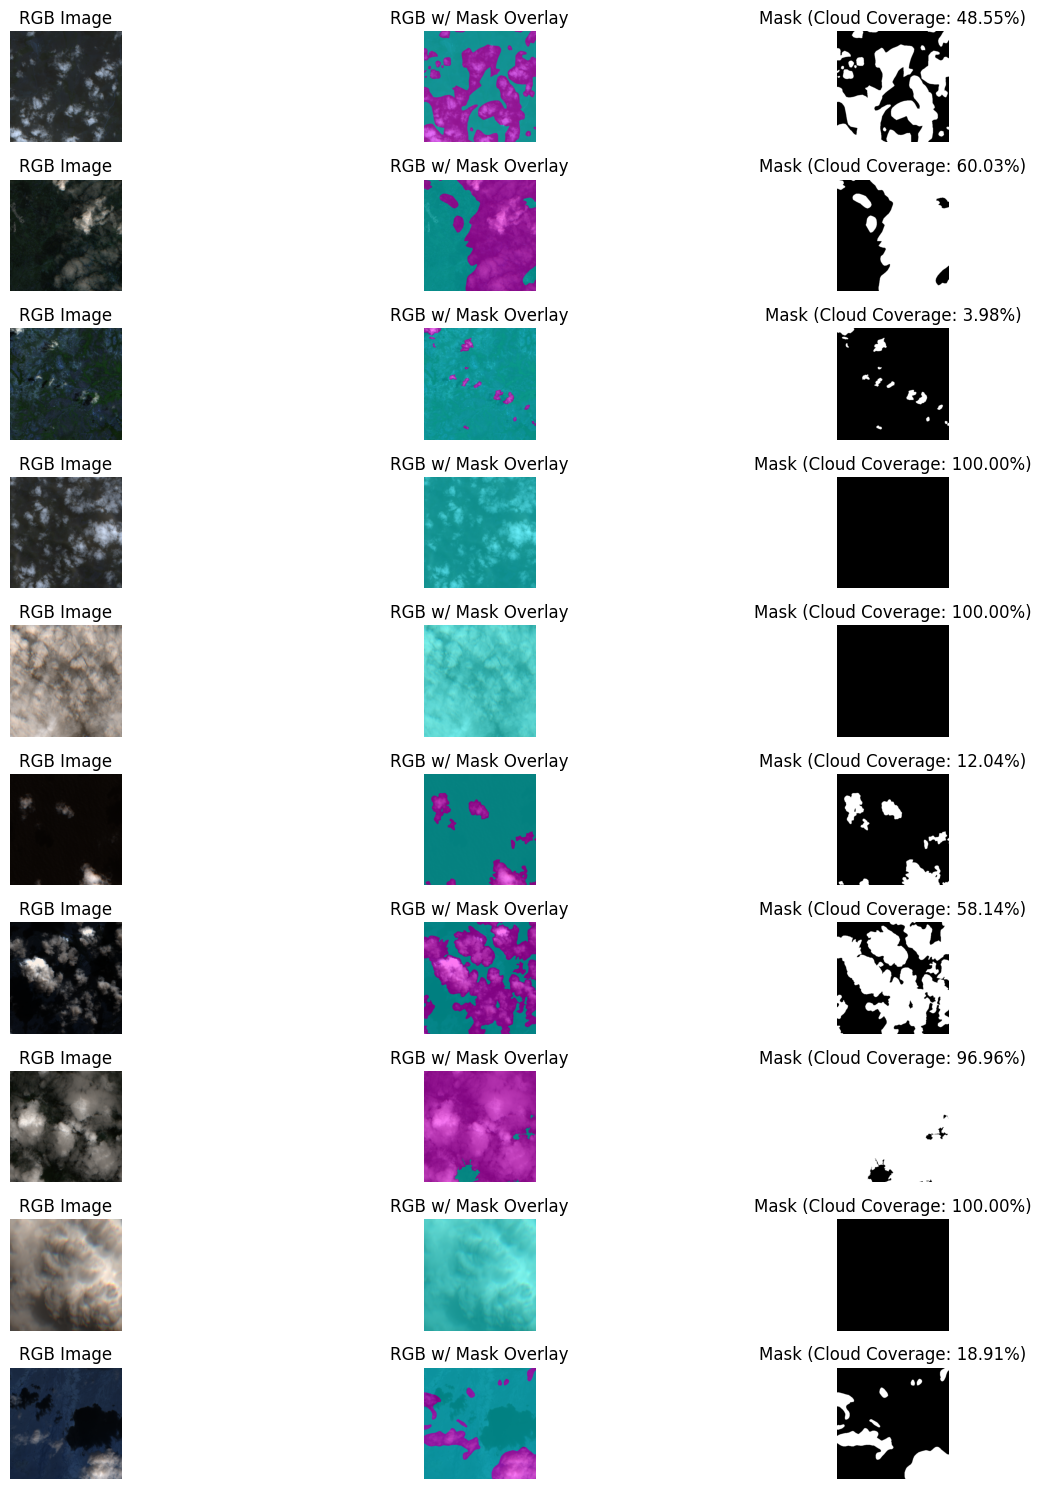

In [13]:
# image_paths, mask_paths = explore_dataset(model=unet_model, lower_threshold=0.01, upper_threshold=0.999)
image_paths, mask_paths = explore_dataset(filenames_to_ignore=filenames_to_ignore)

In [14]:
def save_all_clear_images(image_paths, mask_paths, output_dir="clear_samples", seed=42):
    os.makedirs(output_dir, exist_ok=True)
    clear_indices = []
    print("Scanning for cloud-free masks...")
    for idx, mask_path in enumerate(mask_paths):
        with rasterio.open(mask_path) as msrc:
            mask = msrc.read(1)
            if np.sum(mask > 0) == 0:
                clear_indices.append(idx)

    total_clear = len(clear_indices)
    print(f"Total cloud-free masks: {total_clear} ({100*total_clear/len(mask_paths):.2f}%)")
    if total_clear == 0:
        print("No clear/cloud-free masks found.")
        return

    for i, idx in enumerate(clear_indices):
        with rasterio.open(image_paths[idx]) as imgsrc:
            img = np.stack([imgsrc.read(i+1) for i in range(3)], axis=-1)
            img = (img - img.min())
            if img.max() > 0:
                img = img / img.max()
        with rasterio.open(mask_paths[idx]) as msrc:
            mask = msrc.read(1)

        fname = os.path.splitext(os.path.basename(image_paths[idx]))[0]
        plt.figure(figsize=(9,4))
        plt.subplot(1,2,1)
        plt.imshow(img)
        plt.title("RGB Image")
        plt.axis('off')
        plt.subplot(1,2,2)
        plt.imshow(mask, cmap='gray', vmin=0, vmax=1)
        plt.title("Mask (cloud-free)")
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"{fname}_clear.png"))
        plt.close()

    print(f"Saved {total_clear} image+mask composites in: {output_dir}")

In [15]:
# save_all_clear_images(dataset_images_paths, dataset_masks_paths, output_dir="clear_samples")

In [16]:
# !zip -r clear_samples.zip clear_samples/

In [17]:
train_img_paths, val_img_paths, train_mask_paths, val_mask_paths = train_test_split(
    image_paths, mask_paths, test_size=CONFIG['val_split'], random_state=SEED
)

train_dataset = CloudDataset(train_img_paths, train_mask_paths, transform=train_transform)
val_dataset = CloudDataset(val_img_paths, val_mask_paths, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Training samples: 8329
Validation samples: 2083


In [18]:
def dice_coefficient(y_pred, y_true, smooth=1e-6):
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > 0.5).float()
    
    intersection = torch.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (torch.sum(y_true) + torch.sum(y_pred) + smooth)

def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred_flat = pred.contiguous().view(-1)
    target_flat = target.contiguous().view(-1)
    
    intersection = (pred_flat * target_flat).sum()
    denominator = pred_flat.sum() + target_flat.sum()
    return 1 - (2. * intersection + smooth) / (denominator + smooth)

def jaccard_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    pred_flat = pred.contiguous().view(-1)
    target_flat = target.contiguous().view(-1)
    
    intersection = (pred_flat * target_flat).sum()
    total = (pred_flat + target_flat).sum()
    union = total - intersection
    
    return 1 - (intersection + smooth) / (union + smooth)

def combined_loss(pred, target, metrics=None, 
                 bce_weight=0.5, dice_weight=0.3, jaccard_weight=0.2):
    bce = F.binary_cross_entropy_with_logits(pred, target)
    dice = dice_loss(pred, target)
    jaccard = jaccard_loss(pred, target)
    
    loss = (bce_weight * bce + 
           dice_weight * dice + 
           jaccard_weight * jaccard)
    
    if metrics is not None:
        metrics['bce'] += bce.item() * target.size(0)
        metrics['dice'] += dice.item() * target.size(0)
        metrics['jaccard'] += jaccard.item() * target.size(0)
        metrics['loss'] += loss.item() * target.size(0)
    
    return loss

In [19]:
def get_model(encoder='resnet34'):
    model = smp.Unet(
        encoder_name=encoder,           # Use ResNet34 backbone
        encoder_weights="imagenet",     # Pretrained on ImageNet
        in_channels=4,                  # 4 input channels: RGB + IR
        classes=1,                      # Binary segmentation
        activation="sigmoid",           # Sigmoid for binary segmentation
    )
    
    return model

In [20]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    epoch_loss = 0
    epoch_dice = 0
    scaler = GradScaler()
    
    with tqdm(total=len(loader), desc="Training") as pbar:
        for batch_idx, (data, target) in enumerate(loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()

            with autocast():
                output = model(data)
                loss = combined_loss(output, target)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            epoch_loss += loss.item()
            
            with torch.no_grad():
                dice = dice_coefficient(output, target)
                epoch_dice += dice.item()
            
            pbar.update(1)
            pbar.set_postfix({"loss": epoch_loss/(batch_idx+1), "dice": epoch_dice/(batch_idx+1)})
    
    return epoch_loss / len(loader), epoch_dice / len(loader)

In [21]:
def validate(model, loader, device):
    model.eval()
    val_loss = 0
    val_dice = 0
    
    with torch.no_grad():
        with tqdm(total=len(loader), desc="Validation") as pbar:
            for batch_idx, (data, target) in enumerate(loader):
                data, target = data.to(device), target.to(device)
                
                output = model(data)
                
                loss = combined_loss(output, target)
                val_loss += loss.item()
                
                dice = dice_coefficient(output, target)
                val_dice += dice.item()
                
                pbar.update(1)
                pbar.set_postfix({"val_loss": val_loss/(batch_idx+1), "val_dice": val_dice/(batch_idx+1)})
    
    return val_loss / len(loader), val_dice / len(loader)

In [22]:
def train_model(encoder='resnet34'):
    model = get_model(encoder)
    model = model.to(CONFIG['device'])
    
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
    scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)
    
    writer = SummaryWriter(os.path.join(OUTPUT_DIR, 'logs'))
    
    best_dice = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
    
    print("Starting training...")
    
    for epoch in range(CONFIG['epochs']):
        print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
        
        train_loss, train_dice = train_epoch(model, train_loader, optimizer, CONFIG['device'])
        history['train_loss'].append(train_loss)
        history['train_dice'].append(train_dice)
        
        val_loss, val_dice = validate(model, val_loader, CONFIG['device'])
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        
        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.add_scalar('Loss/val', val_loss, epoch)
        writer.add_scalar('Dice/train', train_dice, epoch)
        writer.add_scalar('Dice/val', val_dice, epoch)
        
        print(f"Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")
        
        scheduler.step()
        
        if val_dice > best_dice:
            best_dice = val_dice
            print(f"Saving best model with Dice coefficient: {best_dice:.4f}")
            torch.save(model.state_dict(), MODEL_PATH.replace('.pkl', '.pt'))
    
    with open(MODEL_PATH, 'wb') as f:
        pickle.dump(model, f)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_dice'], label='Train Dice')
    plt.plot(history['val_dice'], label='Validation Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Coefficient')
    plt.title('Training and Validation Dice Coefficient')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    writer.close()
    
    model.load_state_dict(torch.load(MODEL_PATH.replace('.pkl', '.pt')))
    
    return model

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

/tmp/ipykernel_19/2051035242.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Starting training...

Epoch 1/50


Training:   0%|          | 0/1041 [00:00<?, ?it/s]/tmp/ipykernel_19/2051035242.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Validation: 100%|██████████| 261/261 [00:40<00:00,  6.39it/s, val_loss=0.424, val_dice=0.776]


...

Train Loss: 0.4204, Train Dice: 0.9519
Val Loss: 0.4158, Val Dice: 0.8553

Epoch 49/50


Validation: 100%|██████████| 261/261 [00:24<00:00, 10.56it/s, val_loss=0.416, val_dice=0.886]


Train Loss: 0.4204, Train Dice: 0.9515
Val Loss: 0.4158, Val Dice: 0.8862
Saving best model with Dice coefficient: 0.8862

Epoch 50/50


Validation: 100%|██████████| 261/261 [00:23<00:00, 10.99it/s, val_loss=0.416, val_dice=0.823]


Train Loss: 0.4206, Train Dice: 0.9510
Val Loss: 0.4157, Val Dice: 0.8232


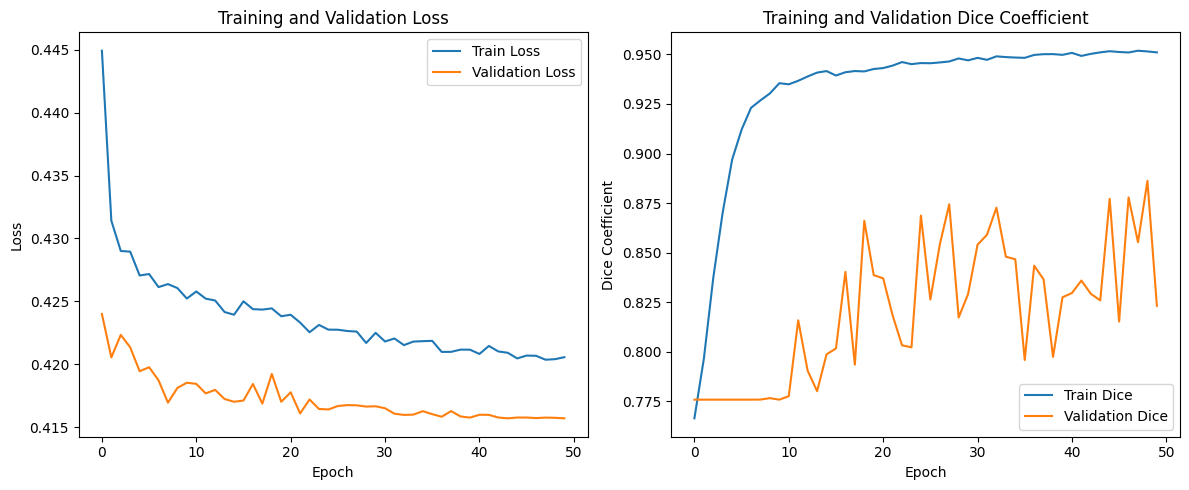

/tmp/ipykernel_19/2936720913.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH.replace('.pkl', '.pt')))


In [23]:
model = train_model()

In [24]:
def visualize_predictions(model, loader, device, num_samples=5):
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    with torch.no_grad():
        for i, (data, target) in enumerate(loader):
            if i >= num_samples:
                break
            
            data, target = data.to(device), target.to(device)
            output = model(data)
            output = (torch.sigmoid(output) > 0.5).float()
            
            img = data[0].permute(1, 2, 0).cpu().numpy()[:, :, :3]  # Use RGB bands
            img = (img - img.min()) / (img.max() - img.min())  # Normalize for visualization
            
            true_mask = target[0, 0].cpu().numpy()
            pred_mask = output[0, 0].cpu().numpy()
            
            axes[i, 0].imshow(img)
            axes[i, 0].set_title("Image (RGB)")
            axes[i, 0].axis("off")
            
            axes[i, 1].imshow(true_mask, cmap="gray")
            axes[i, 1].set_title("Ground Truth")
            axes[i, 1].axis("off")
            
            axes[i, 2].imshow(pred_mask, cmap="gray")
            axes[i, 2].set_title("Prediction")
            axes[i, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

In [25]:
def analyze_worst_cases(model, loader, device, num_samples=5):
    model.eval()
    
    results = []
    
    with torch.no_grad():
        for i, (data, target) in enumerate(loader):
            data, target = data.to(device), target.to(device)
            output = model(data)
            output = torch.sigmoid(output)
            
            for j in range(data.size(0)):
                pred = (output[j] > 0.5).float()
                truth = target[j]
                
                intersection = torch.sum(truth * pred)
                dice = (2. * intersection) / (torch.sum(truth) + torch.sum(pred) + 1e-6)
                
                results.append({
                    'dice': dice.item(),
                    'data': data[j].cpu(),
                    'target': target[j].cpu(),
                    'output': output[j].cpu()
                })
    
    results.sort(key=lambda x: x['dice'])
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    for i in range(num_samples):
        img = results[i]['data'].permute(1, 2, 0).numpy()[:, :, :3]
        img = (img - img.min()) / (img.max() - img.min())  # Normalize for visualization
        
        true_mask = results[i]['target'][0].numpy()
        pred_mask = (results[i]['output'][0] > 0.5).float().numpy()
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Image (RGB)")
        axes[i, 0].axis("off")
        
        axes[i, 1].imshow(true_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")
        
        axes[i, 2].imshow(pred_mask, cmap="gray")
        title = f"Prediction (Dice = {results[i]['dice']:.4f})"
        axes[i, 2].set_title(title)
        axes[i, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

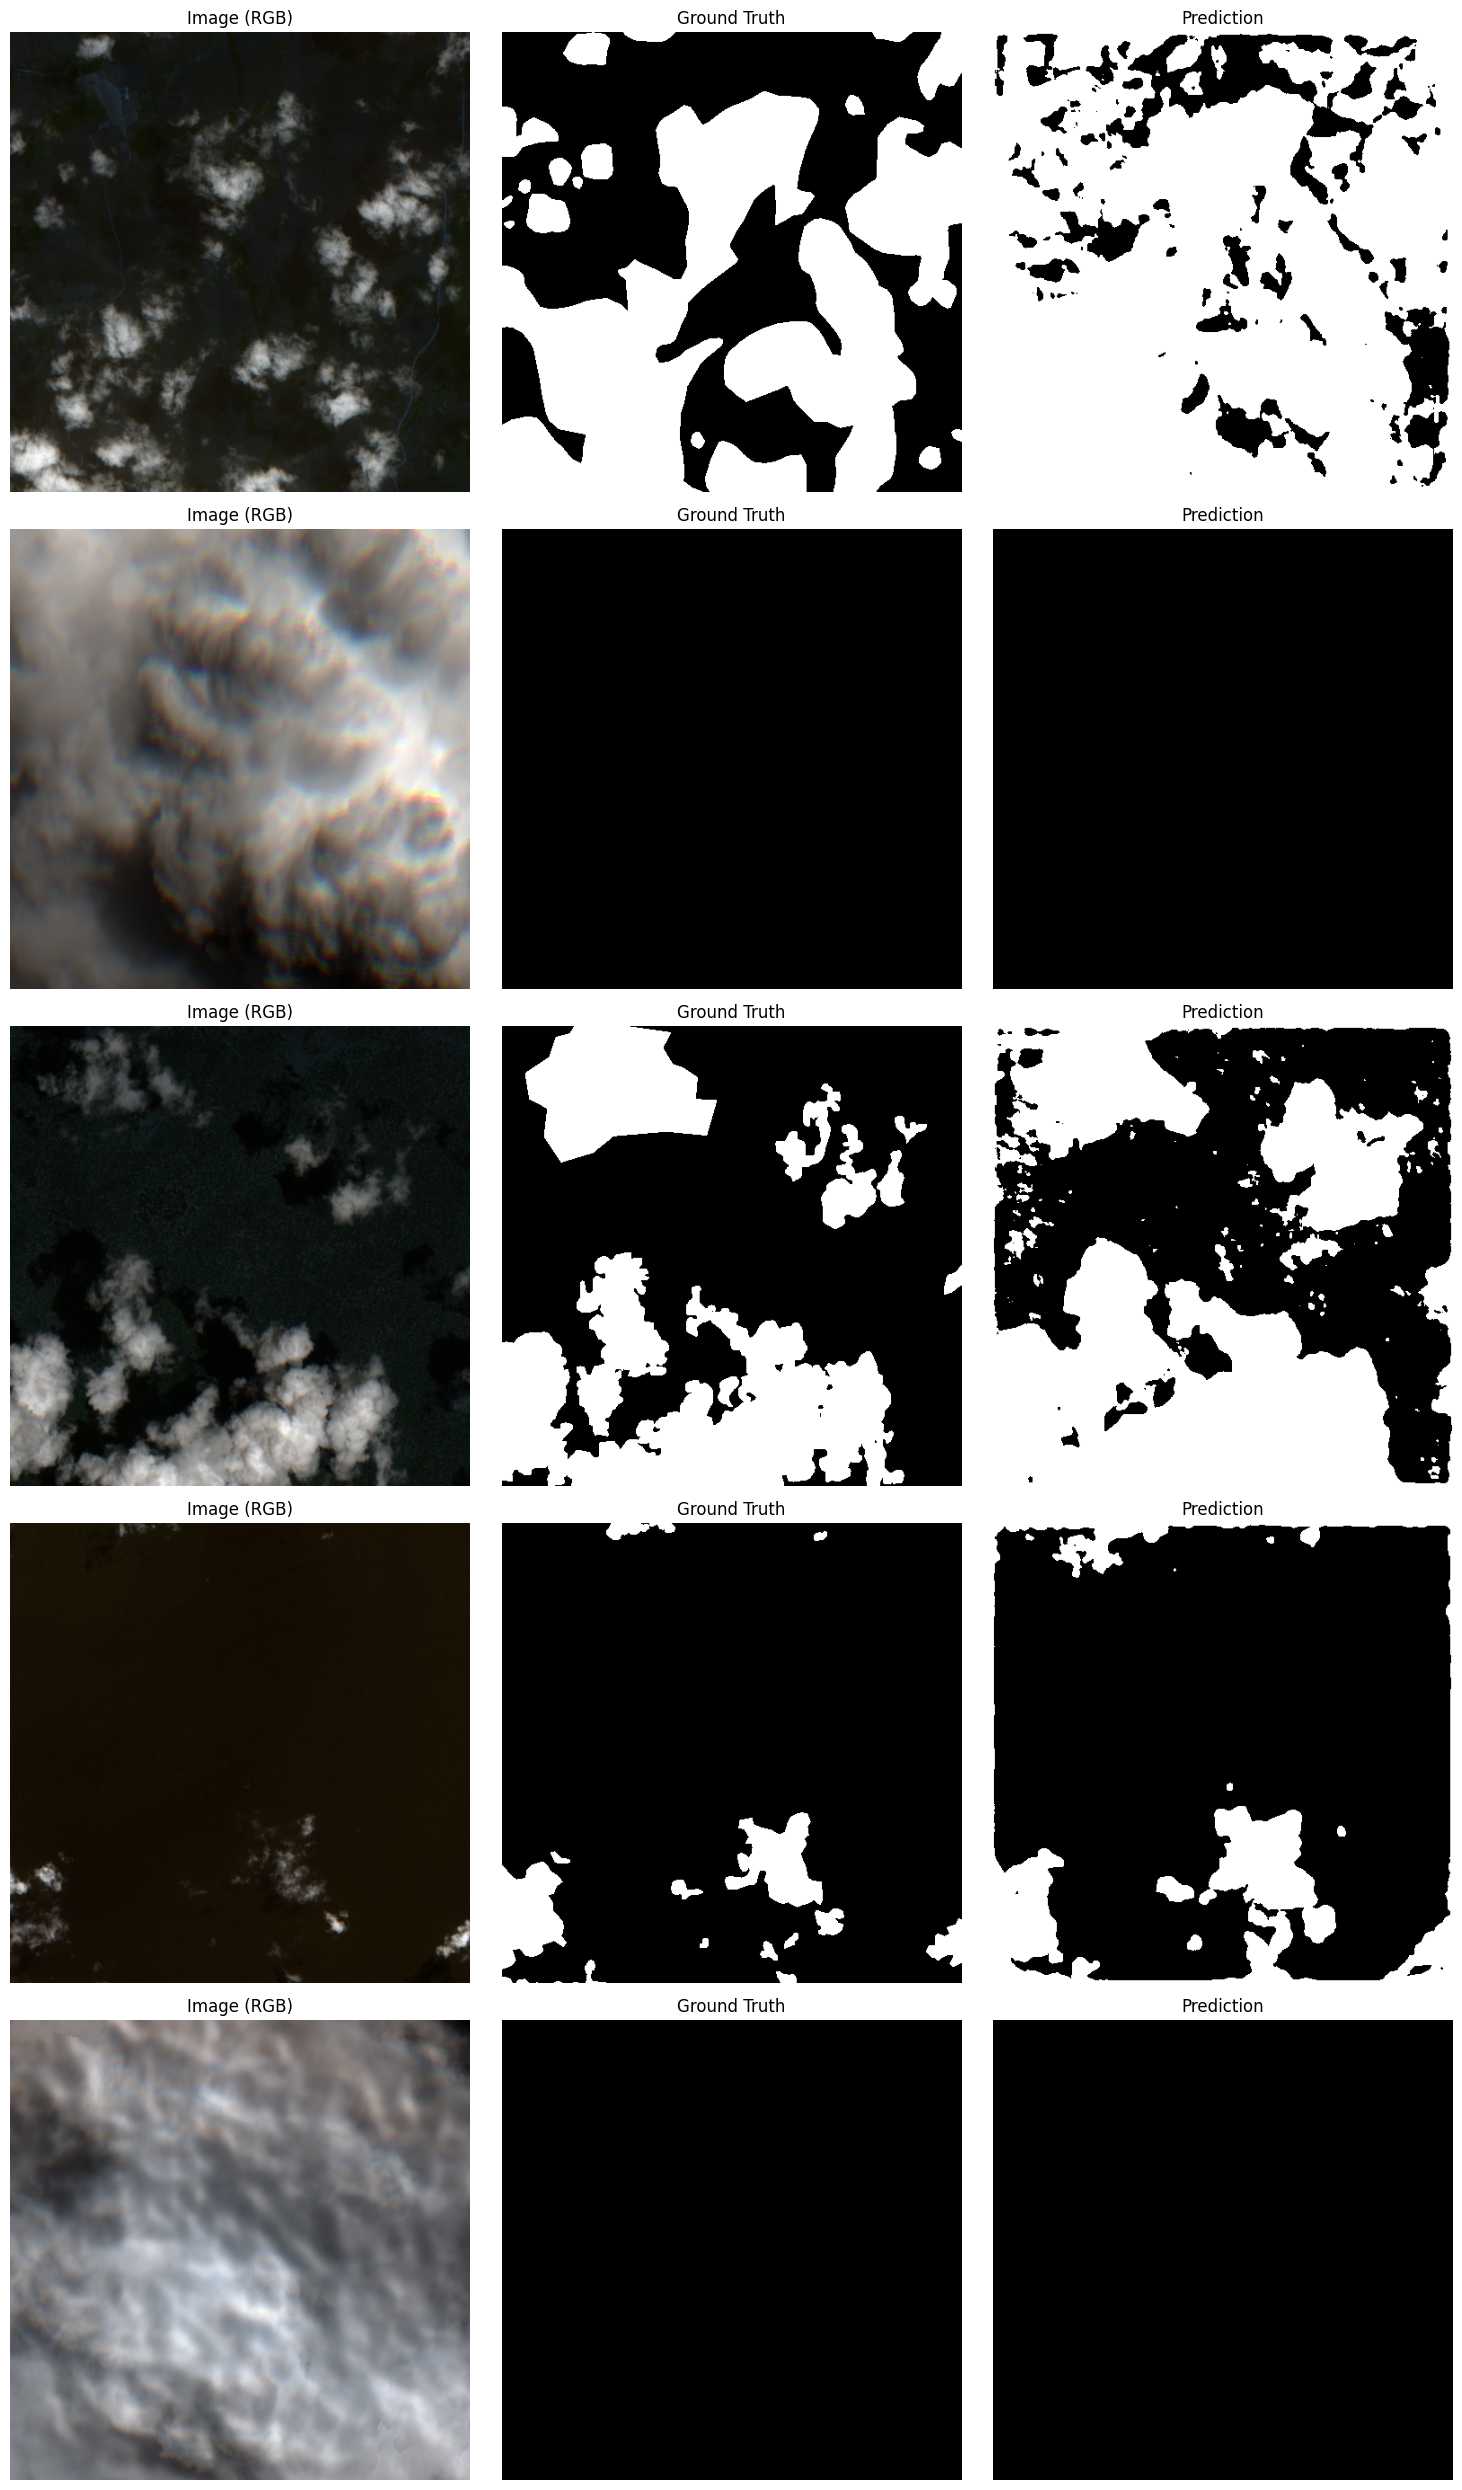

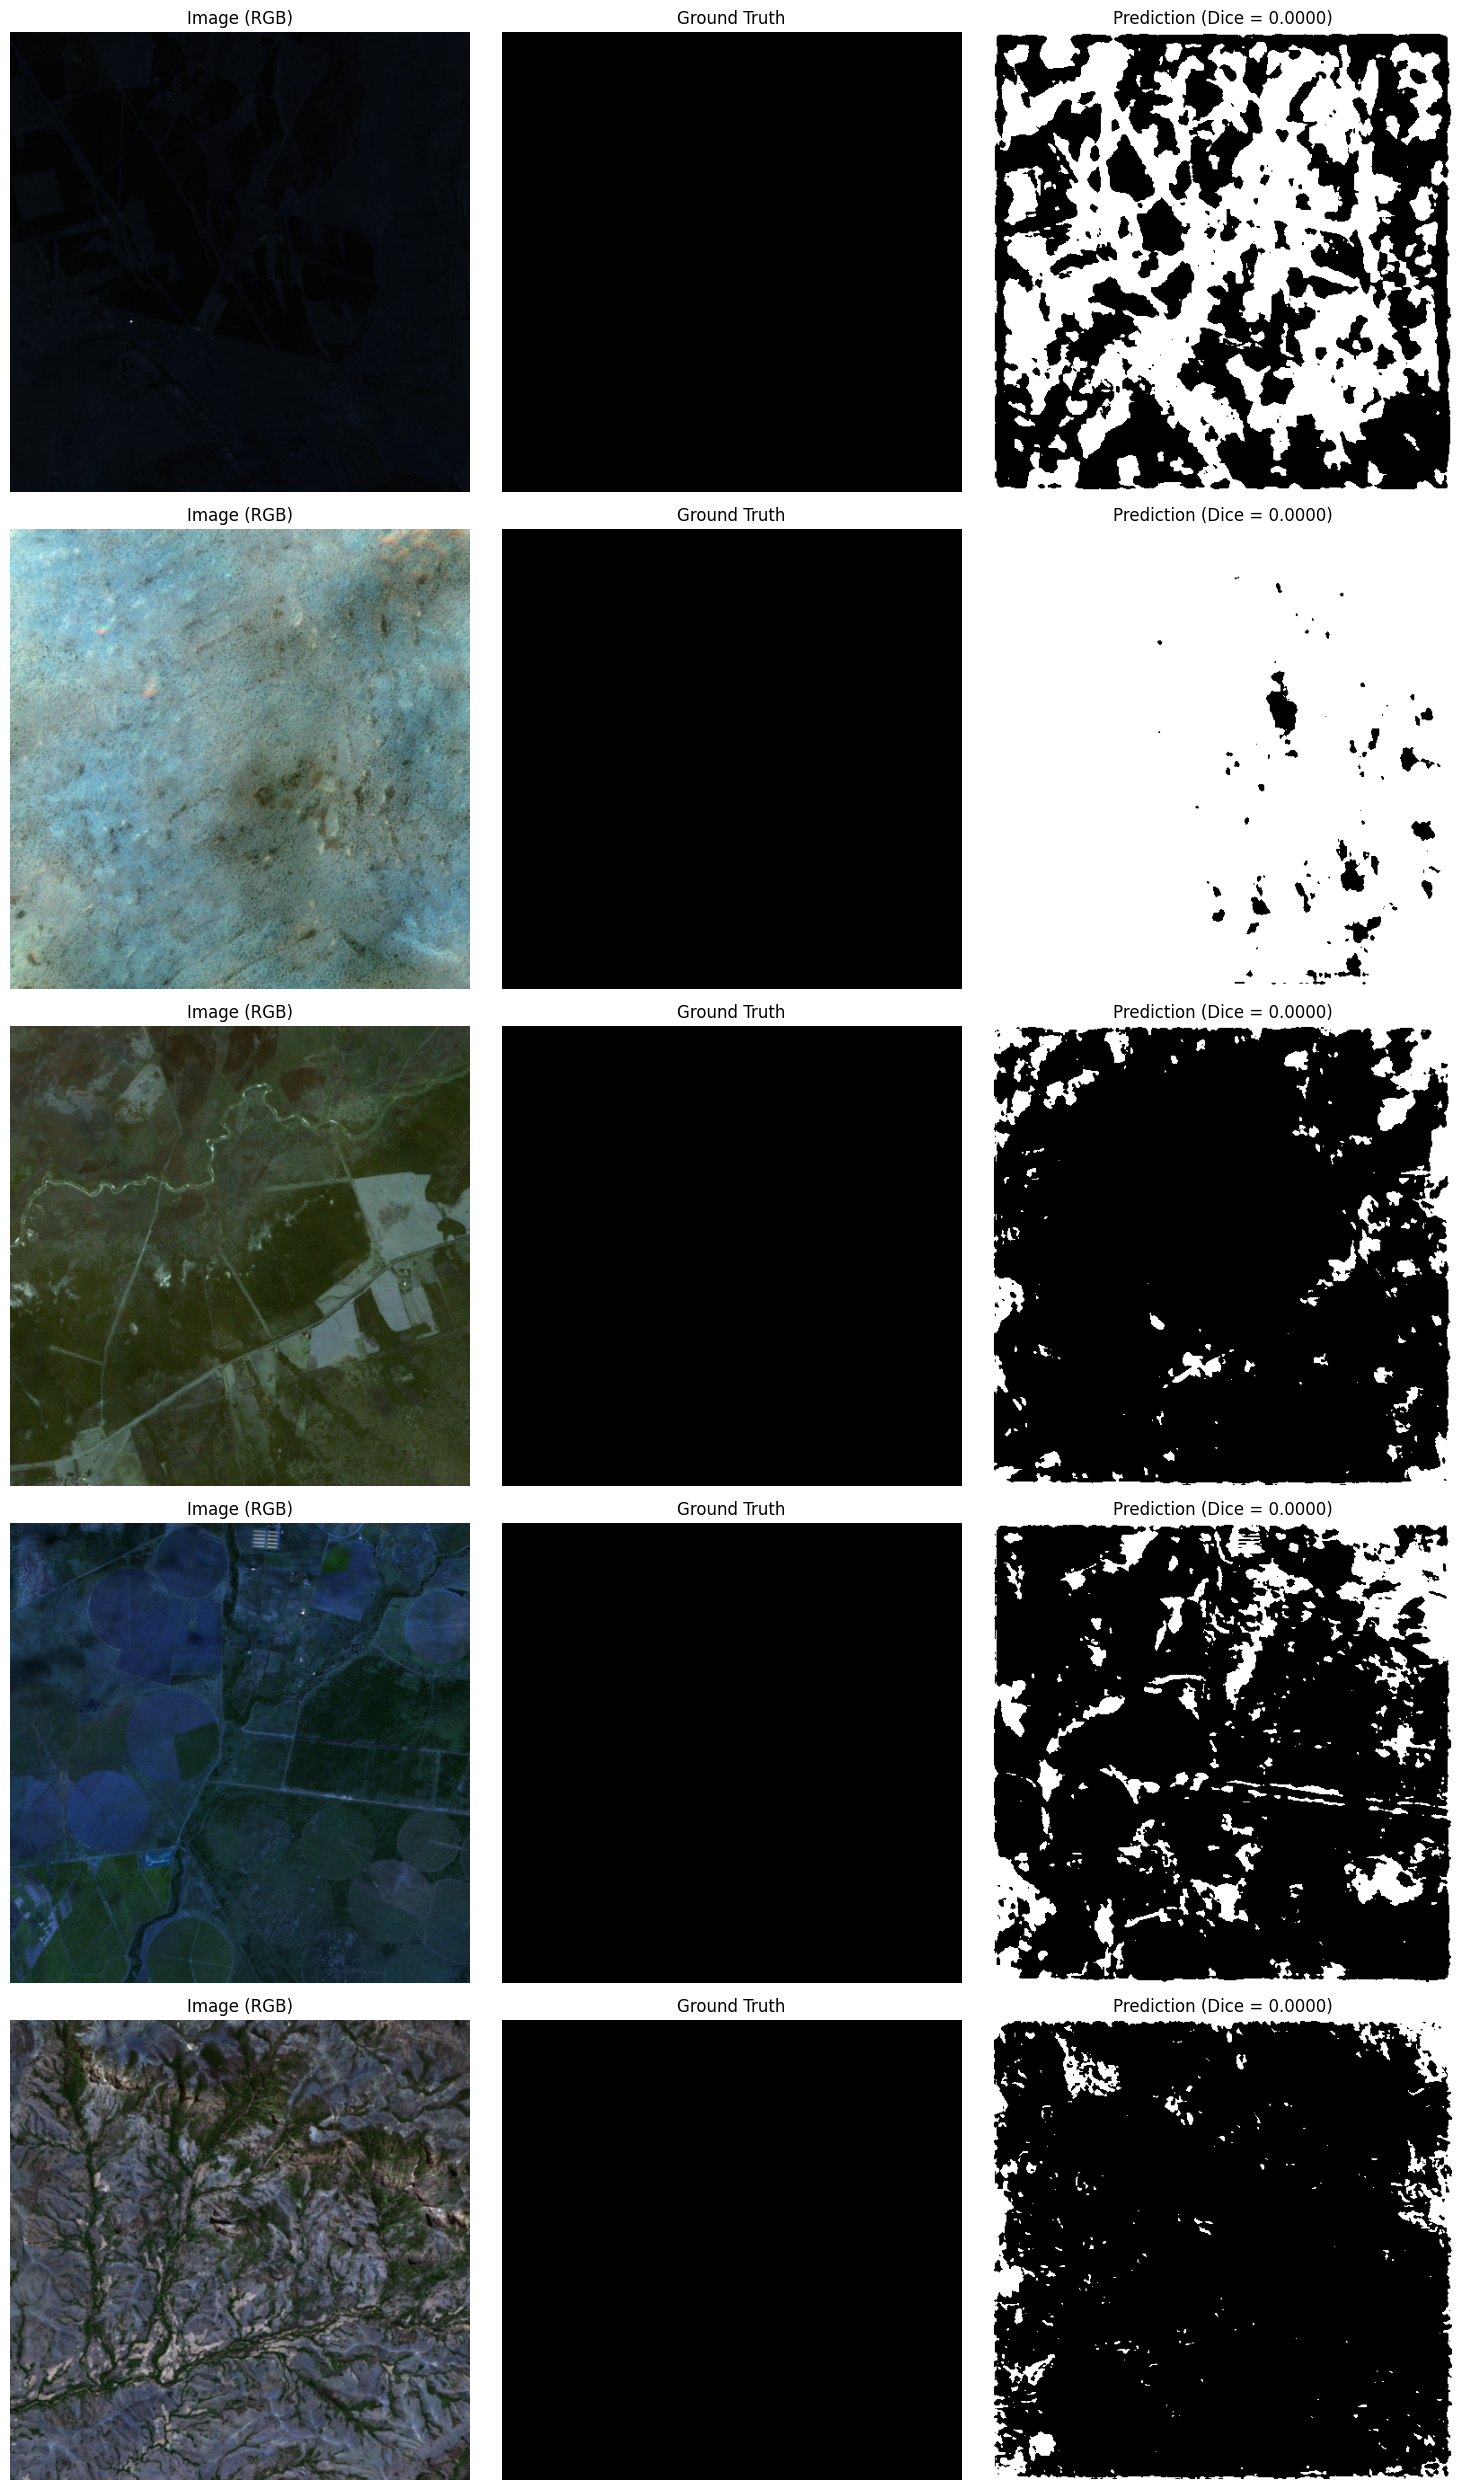

In [26]:
visualize_predictions(model, val_loader, CONFIG['device'])
analyze_worst_cases(model, val_loader, CONFIG['device'])

In [27]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def profile_model(model):    
    input_tensor = torch.randn(1, 4, CONFIG['img_size'], CONFIG['img_size']).to(CONFIG['device'])
    
    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        profile_memory=True,
        record_shapes=True
    ) as prof:
        with record_function("model_inference"):
            _ = model(input_tensor)
    
    flops_estimate = prof.key_averages().total_average().flops    
    total_params = count_parameters(model)
    
    with open(LOGS_PATH, 'w') as f:
        f.write(f"Model: UNet with ResNet34 backbone\n")
        f.write(f"Total parameters: {total_params:,}\n")
        if flops_estimate:
            f.write(f"Estimated FLOPs: {flops_estimate:,}\n")
        else:
            f.write(f"Operations: Profile data available in tensorboard logs\n")
        f.write(f"Input shape: (4, {CONFIG['img_size']}, {CONFIG['img_size']})\n")
        f.write(f"Output shape: (1, {CONFIG['img_size']}, {CONFIG['img_size']})\n")
    
    print(f"Model statistics:")
    print(f"- Total parameters: {total_params:,}")
    if flops_estimate:
        print(f"- Estimated FLOPs: {flops_estimate:,}")
    print(f"- Profile data written to {LOGS_PATH}")

In [28]:
profile_model(model)

Model statistics:
- Total parameters: 24,439,505
- Profile data written to /kaggle/working/model_logs.txt
